In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [2]:
df = pd.read_csv("insurance.csv")
print("Dataset loaded successfully!")
print()

Dataset loaded successfully!



In [3]:
print("First 5 rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())



First 5 rows:
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

Dataset Shape:
(1338, 7)

Column Names:
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

Data Types:
age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

Missing Values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Statistical Summary:
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094

In [4]:

X = df[["bmi"]]


y = df["charges"]


print("Independent Variable:")
print("BMI")

print("\nDependent Variable:")
print("Charges")

print("\nX shape:", X.shape)
print("y shape:", y.shape)


Independent Variable:
BMI

Dependent Variable:
Charges

X shape: (1338, 1)
y shape: (1338,)


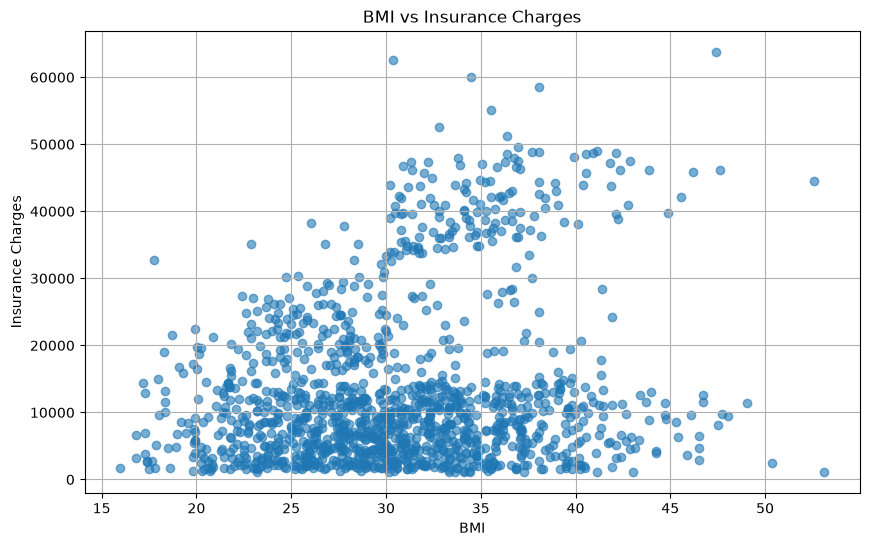

In [5]:
plt.figure(figsize=(10, 6))

plt.scatter(
    X["bmi"],
    y,
    alpha=0.6
)

plt.xlabel("BMI")
plt.ylabel("Insurance Charges")
plt.title("BMI vs Insurance Charges")
plt.grid(True)

plt.show()


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining percentage:",
      len(X_train) / len(X) * 100, "%")

print("Testing percentage:",
      len(X_test) / len(X) * 100, "%")

Training samples: 1070
Testing samples: 268

Training percentage: 79.97010463378177 %
Testing percentage: 20.029895366218238 %


In [7]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

print("==============================")
print("LINEAR REGRESSION")
print("==============================")

print("Slope:", linear_model.coef_[0])
print("Intercept:", linear_model.intercept_)

print("R² Score:",
      r2_score(y_test, y_pred_linear))

print("MAE:",
      mean_absolute_error(y_test, y_pred_linear))

print("MSE:",
      mean_squared_error(y_test, y_pred_linear))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, y_pred_linear)))

LINEAR REGRESSION
Slope: 392.4365441698801
Intercept: 1353.0730722046574
R² Score: 0.03970193117941878
MAE: 9784.65259627133
MSE: 149085057.03839505
RMSE: 12210.039190698571


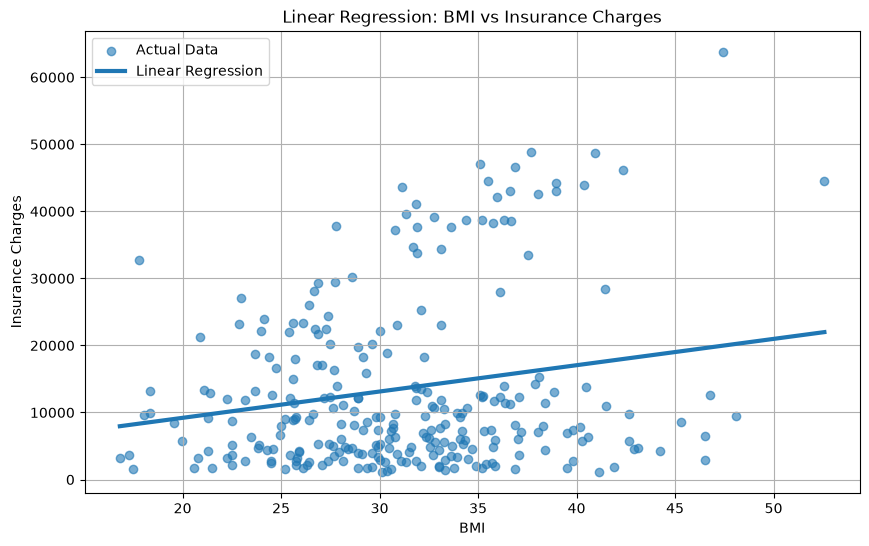

In [8]:
plt.figure(figsize=(10, 6))

plt.scatter(
    X_test["bmi"],
    y_test,
    alpha=0.6,
    label="Actual Data"
)

sort_index = np.argsort(X_test["bmi"].values)

X_test_sorted = X_test.iloc[sort_index]

y_linear_sorted = linear_model.predict(X_test_sorted)

plt.plot(
    X_test_sorted["bmi"],
    y_linear_sorted,
    linewidth=3,
    label="Linear Regression"
)

plt.xlabel("BMI")
plt.ylabel("Insurance Charges")
plt.title("Linear Regression: BMI vs Insurance Charges")

plt.legend()
plt.grid(True)

plt.show()

In [9]:
def polynomial_regression(degree):

    # Create polynomial features
    poly = PolynomialFeatures(
        degree=degree,
        include_bias=False
    )

    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    # Create Linear Regression model
    model = LinearRegression()

    # Train model
    model.fit(X_train_poly, y_train)

    # Predictions
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)

    # Evaluation
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    test_mae = mean_absolute_error(
        y_test,
        y_test_pred
    )

    test_mse = mean_squared_error(
        y_test,
        y_test_pred
    )

    test_rmse = np.sqrt(test_mse)

    return (
        poly,
        model,
        y_test_pred,
        train_r2,
        test_r2,
        test_mae,
        test_mse,
        test_rmse
    )

In [10]:
degrees = [2, 3, 4, 5]

results = []

for degree in degrees:

    (
        poly,
        model,
        predictions,
        train_r2,
        test_r2,
        mae,
        mse,
        rmse
    ) = polynomial_regression(degree)

    results.append([
        degree,
        train_r2,
        test_r2,
        mae,
        mse,
        rmse
    ])

In [11]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Degree",
        "Training R2",
        "Testing R2",
        "MAE",
        "MSE",
        "RMSE"
    ]
)

print("==============================")
print("POLYNOMIAL REGRESSION RESULTS")
print("==============================")

print(results_df)

POLYNOMIAL REGRESSION RESULTS
   Degree  Training R2  Testing R2          MAE           MSE          RMSE
0       2     0.041558    0.030763  9823.701955  1.504728e+08  12266.733504
1       3     0.045290    0.018011  9863.434995  1.524525e+08  12347.166300
2       4     0.045494    0.014597  9864.876317  1.529825e+08  12368.609295
3       5     0.045482    0.012994  9866.056436  1.532314e+08  12378.667905


c:\Users\Aryan\Desktop\ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
c:\Users\Aryan\Desktop\ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
c:\Users\Aryan\Desktop\ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
c:\Users\Aryan\Desktop\ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


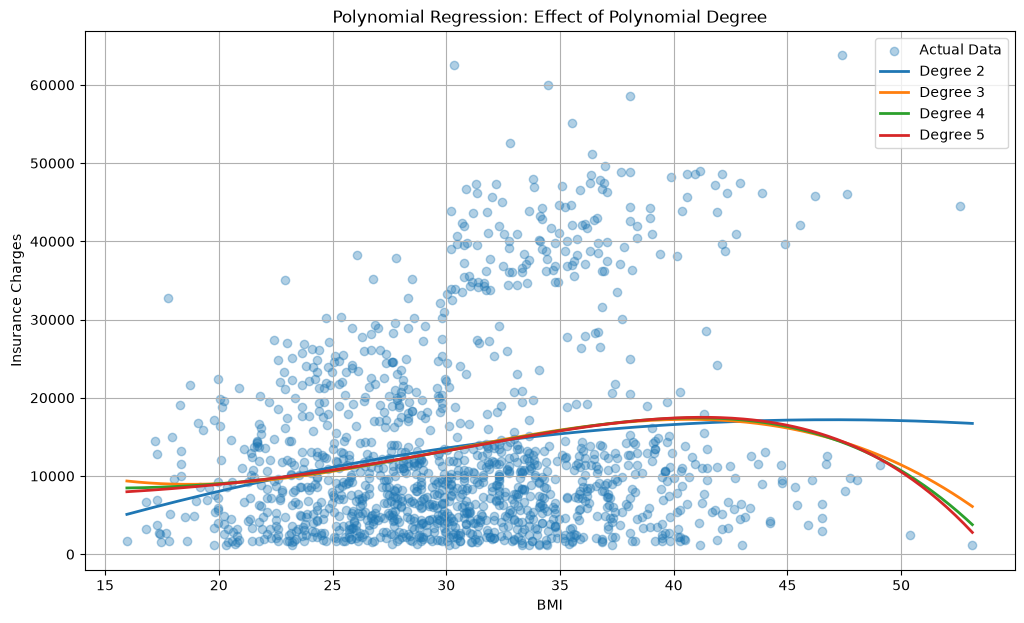

In [12]:
bmi_range = np.linspace(
    X["bmi"].min(),
    X["bmi"].max(),
    300
).reshape(-1, 1)

plt.figure(figsize=(12, 7))

# Actual data
plt.scatter(
    X["bmi"],
    y,
    alpha=0.35,
    label="Actual Data"
)

# Polynomial curves
for degree in degrees:

    poly = PolynomialFeatures(
        degree=degree,
        include_bias=False
    )

    X_poly = poly.fit_transform(X_train)

    model = LinearRegression()

    model.fit(X_poly, y_train)

    bmi_poly = poly.transform(bmi_range)

    predictions = model.predict(bmi_poly)

    plt.plot(
        bmi_range,
        predictions,
        linewidth=2,
        label=f"Degree {degree}"
    )

plt.xlabel("BMI")
plt.ylabel("Insurance Charges")

plt.title(
    "Polynomial Regression: Effect of Polynomial Degree"
)

plt.legend()
plt.grid(True)

plt.show()

In [13]:
new_bmi = np.array([[30]])

print("==============================")
print("PREDICTION FOR NEW BMI")
print("==============================")

for degree in [2, 3, 4, 5]:

    poly = PolynomialFeatures(
        degree=degree,
        include_bias=False
    )

    X_train_poly = poly.fit_transform(X_train)

    model = LinearRegression()

    model.fit(X_train_poly, y_train)

    new_bmi_poly = poly.transform(new_bmi)

    predicted_charge = model.predict(new_bmi_poly)

    print(
        f"Degree {degree}: "
        f"Predicted insurance charge = "
        f"{predicted_charge[0]:.2f}"
    )

PREDICTION FOR NEW BMI
Degree 2: Predicted insurance charge = 13569.38
Degree 3: Predicted insurance charge = 13275.11
Degree 4: Predicted insurance charge = 13209.50
Degree 5: Predicted insurance charge = 13206.14


c:\Users\Aryan\Desktop\ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
c:\Users\Aryan\Desktop\ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
c:\Users\Aryan\Desktop\ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
c:\Users\Aryan\Desktop\ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


In [14]:
poly_demo = PolynomialFeatures(
    degree=3,
    include_bias=False
)

demo_features = poly_demo.fit_transform(
    np.array([[20], [25], [30]])
)

demo_df = pd.DataFrame(
    demo_features,
    columns=["BMI", "BMI²", "BMI³"]
)

print("==============================")
print("POLYNOMIAL FEATURE GENERATION")
print("==============================")

print(demo_df)

POLYNOMIAL FEATURE GENERATION
    BMI   BMI²     BMI³
0  20.0  400.0   8000.0
1  25.0  625.0  15625.0
2  30.0  900.0  27000.0


In [15]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import numpy as np

results = []

for degree in range(1, 6):
    poly = PolynomialFeatures(degree=degree)
    
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    
    y_pred = model.predict(X_test_poly)
    
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    results.append([degree, mse, rmse, r2])

results_df = pd.DataFrame(
    results,
    columns=["Degree", "MSE", "RMSE", "R2 Score"]
)

print(results_df)

   Degree           MSE          RMSE  R2 Score
0       1  1.490851e+08  12210.039191  0.039702
1       2  1.504728e+08  12266.733504  0.030763
2       3  1.524525e+08  12347.166300  0.018011
3       4  1.529825e+08  12368.609295  0.014597
4       5  1.532314e+08  12378.667905  0.012994


In [16]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import numpy as np

results = []

for degree in range(1, 6):

    poly = PolynomialFeatures(degree=degree)

    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    y_pred = model.predict(X_test_poly)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append([
        degree,
        r2,
        mse,
        rmse
    ])

results_df = pd.DataFrame(
    results,
    columns=["Degree", "R2 Score", "MSE", "RMSE"]
)

print("==============================================")
print("     POLYNOMIAL REGRESSION COMPARISON")
print("==============================================")
print(results_df.to_string(index=False))

best_degree = results_df.loc[
    results_df["R2 Score"].idxmax(), "Degree"
]

best_r2 = results_df["R2 Score"].max()

print("\n==============================================")
print("BEST MODEL")
print("==============================================")
print("Best Degree:", best_degree)
print("Best R2 Score:", round(best_r2, 4))
print("R2 Percentage:", round(best_r2 * 100, 2), "%")

     POLYNOMIAL REGRESSION COMPARISON
 Degree  R2 Score          MSE         RMSE
      1  0.039702 1.490851e+08 12210.039191
      2  0.030763 1.504728e+08 12266.733504
      3  0.018011 1.524525e+08 12347.166300
      4  0.014597 1.529825e+08 12368.609295
      5  0.012994 1.532314e+08 12378.667905

BEST MODEL
Best Degree: 1
Best R2 Score: 0.0397
R2 Percentage: 3.97 %
